w= [0.57773487] [0.64686834] [0.8778243] [0.14292397]
w2,w3= 0.10887390297878796 0.6651476868777612
b1,b2= [0.09323513] [-4.14859614]


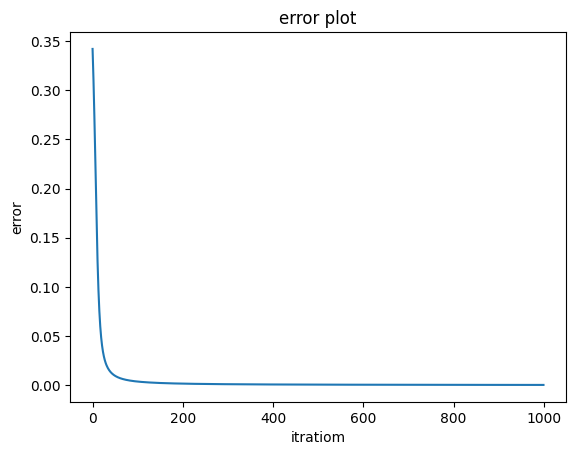

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x1=np.array([0])
x2=np.array([0])
y=[0] # target
earray=[]
itra=[]

w00=np.random.rand() #weights for hidden layer
w01=np.random.rand() #weights for hidden layer
w10=np.random.rand() #weights for hidden layer
w11=np.random.rand() #weights for hidden layer

b1=1.0 #bias for hidden layer

w2=np.random.rand()#weights for outputlayer

w3=np.random.rand()#weights for output layer

b2=1.0   #bias for output layer

iterations=1000


for itr in range(iterations):

    #forward propogation
    #input layer to hidden layer
    z1=w00*x1+w01*x2+b1 # hidden layer z1
    z2=w10*x1+w11*x2+b1 # hidden layer z2


    h1=1/(1+np.exp(-z1))# hidden layer h1
    h2=1/(1+np.exp(-z2))# hidden layer h2
    #forward propogation
    # hidden layer to output layer
    zout=w2*h1+w3*h2+b2 # output  layer z
    o=1/(1+np.exp(-zout))# output  layer output o


    #Back propogation
    #output to hidden layer
    # gradient determination
    # Error calculation Mean squared error: e = 0.5 * (o - y)^2.

    e=0.5*np.mean((o-y)*(o-y))
    de_do=o-y
    do_dzout=o*(1-o)
    dzout_dw2=h1
    dzout_dw3=h2
    dzout_db2=1

    #de_dw2
    de_dw2=de_do*do_dzout*dzout_dw2
    #de_dw3
    de_dw3=de_do*do_dzout*dzout_dw3
    #de_db2
    de_db2=de_do*do_dzout*dzout_db2

    # Backpropagation hidden layer to input layer
    # Compute gradients step by step using the chain rule.
    # Gradients for output layer weights (w2, w3, b2).
    # Gradients for hidden layer weights (w00, w01, w10, w11, b1).

    dzout_dh1=w2
    dh1_dz1=h1*(1-h1)
    dzout_dh2=w3
    dh2_dz2=h2*(1-h2)
    dz1_dw00=x1
    dz2_dw01=x2
    dz1_dw10=x1
    dz2_dw11=x2
    dz1_db1=1
    dz2_db1=1

    #de_dw00
    de_dw00=de_do*do_dzout*dzout_dh1*dh1_dz1*dz1_dw00
    #de_dw01
    de_dw01=de_do*do_dzout*dzout_dh2*dh2_dz2*dz2_dw01
    #de_dw10
    de_dw10=de_do*do_dzout*dzout_dh1*dh1_dz1*dz1_dw10
    #de_dw11
    de_dw11=de_do*do_dzout*dzout_dh2*dh2_dz2*dz2_dw11
    #de_db1
    de_db1=de_do*do_dzout*dzout_dh1*dh1_dz1*dz1_db1+de_do*do_dzout*dzout_dh2*dh2_dz2*dz2_db1

    # Udates Subtract gradients from each weight and bias
    # (learning rate is implicitly 1, since you didn’t scale the updates).

    w00-=de_dw00
    w01-=de_dw01
    w10-=de_dw10
    w11-=de_dw11
    b1-=de_db1
    b2-=de_db2
    earray.append(np.mean(e))
    itra.append(itr)


plt.ylabel("error")
plt.xlabel("itratiom")
plt.title("error plot")
plt.plot(itra,earray)
print("w=",w00,w01,w10,w11)
print("w2,w3=",w2,w3)
print("b1,b2=",b1,b2)

/tmp/ipython-input-2581680172.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  g_log["dw00"].append(float(de_dw00)); g_log["dw01"].append(float(de_dw01))
/tmp/ipython-input-2581680172.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  g_log["dw10"].append(float(de_dw10)); g_log["dw11"].append(float(de_dw11))
/tmp/ipython-input-2581680172.py:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  g_log["dw2"].append(float(de_dw2));   g_log["dw3"].append(float(de_dw3

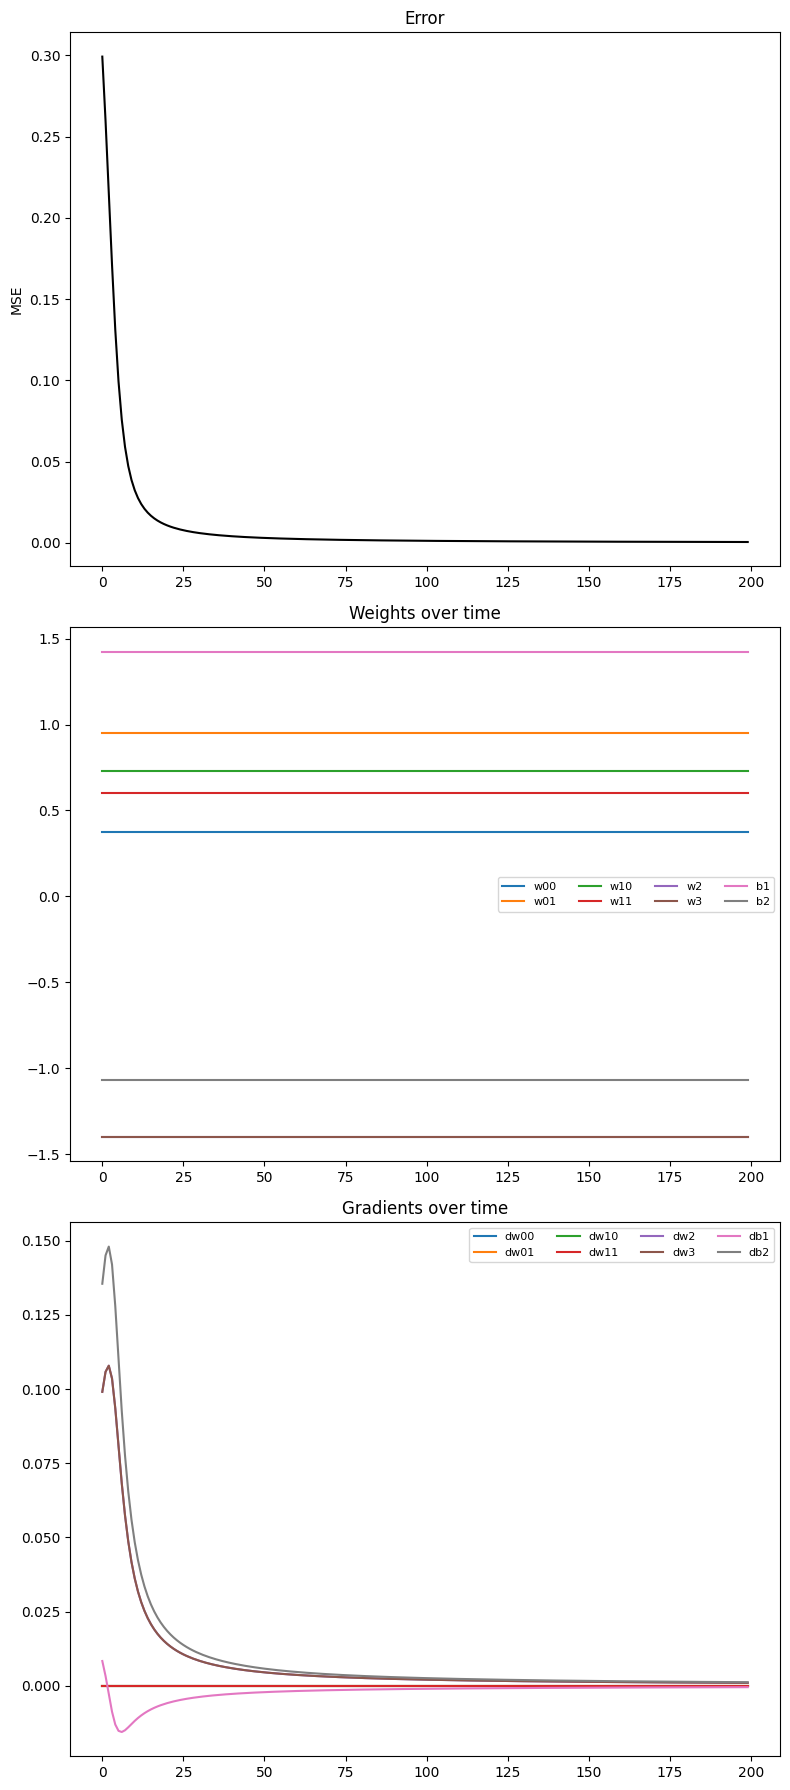

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x1=np.array([0])
x2=np.array([0])
y=[0] # target

# Random init
np.random.seed(42)
w00=np.random.rand()
w01=np.random.rand()
w10=np.random.rand()
w11=np.random.rand()
b1=1.0
w2=np.random.rand()
w3=np.random.rand()
b2=1.0

iterations=200

# logs
earray=[]
itra=[]
w_log = {"w00":[],"w01":[],"w10":[],"w11":[],"w2":[],"w3":[],"b1":[],"b2":[]}
g_log = {"dw00":[],"dw01":[],"dw10":[],"dw11":[],"dw2":[],"dw3":[],"db1":[],"db2":[]}

for itr in range(iterations):

    #forward
    z1=w00*x1+w01*x2+b1
    z2=w10*x1+w11*x2+b1
    h1=1/(1+np.exp(-z1))
    h2=1/(1+np.exp(-z2))
    zout=w2*h1+w3*h2+b2
    o=1/(1+np.exp(-zout))

    #error
    e=0.5*np.mean((o-y)*(o-y))
    de_do=o-y
    do_dzout=o*(1-o)

    #output layer grads
    de_dw2=de_do*do_dzout*h1
    de_dw3=de_do*do_dzout*h2
    de_db2=de_do*do_dzout*1

    #hidden grads
    dzout_dh1=w2; dh1_dz1=h1*(1-h1)
    dzout_dh2=w3; dh2_dz2=h2*(1-h2)

    de_dw00=de_do*do_dzout*dzout_dh1*dh1_dz1*x1
    de_dw01=de_do*do_dzout*dzout_dh2*dh2_dz2*x2
    de_dw10=de_do*do_dzout*dzout_dh1*dh1_dz1*x1
    de_dw11=de_do*do_dzout*dzout_dh2*dh2_dz2*x2
    de_db1=de_do*do_dzout*(dzout_dh1*dh1_dz1 + dzout_dh2*dh2_dz2)*1

    #update
    w00-=de_dw00; w01-=de_dw01; w10-=de_dw10; w11-=de_dw11
    b1-=de_db1
    w2-=de_dw2; w3-=de_dw3
    b2-=de_db2

    # logs
    itra.append(itr)
    earray.append(e)
    w_log["w00"].append(w00); w_log["w01"].append(w01)
    w_log["w10"].append(w10); w_log["w11"].append(w11)
    w_log["w2"].append(w2);   w_log["w3"].append(w3)
    w_log["b1"].append(b1);   w_log["b2"].append(b2)

    g_log["dw00"].append(float(de_dw00)); g_log["dw01"].append(float(de_dw01))
    g_log["dw10"].append(float(de_dw10)); g_log["dw11"].append(float(de_dw11))
    g_log["dw2"].append(float(de_dw2));   g_log["dw3"].append(float(de_dw3))
    g_log["db1"].append(float(de_db1));   g_log["db2"].append(float(de_db2))

# ---- PLOTS ----
plt.figure(figsize=(8,18))

# Error
plt.subplot(3,1,1)
plt.plot(itra, earray, 'k')
plt.title("Error")
plt.ylabel("MSE")

# Weights
plt.subplot(3,1,2)
for k,v in w_log.items():
    plt.plot(itra, v, label=k)
plt.title("Weights over time")
plt.legend(loc="best", ncol=4, fontsize=8)

# Gradients
plt.subplot(3,1,3)
for k,v in g_log.items():
    plt.plot(itra, v, label=k)
plt.title("Gradients over time")
plt.legend(loc="best", ncol=4, fontsize=8)


# bias -


plt.tight_layout()
plt.show()


**1. Learning Rate(𝜂)=0.1**

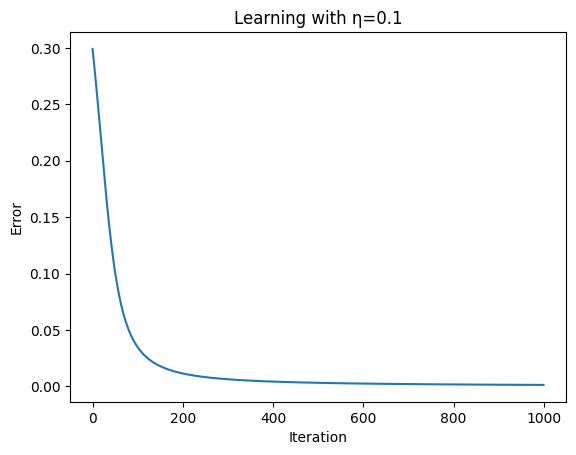

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x1=np.array([0])
x2=np.array([0])
y=[0] # target


# Learning rate (try 0.01, 0.1, 1.0)
eta = 0.1

# Random initialization
np.random.seed(42)
w00, w01, w10, w11 = np.random.rand(4)
b1 = 1.0
w2, w3 = np.random.rand(2)
b2 = 1.0

earray=[]
itra=[]
iterations=1000

for itr in range(iterations):
    # Forward pass
    z1=w00*x1+w01*x2+b1
    z2=w10*x1+w11*x2+b1
    h1=1/(1+np.exp(-z1))
    h2=1/(1+np.exp(-z2))
    zout=w2*h1+w3*h2+b2
    o=1/(1+np.exp(-zout))

    # Error
    e=0.5*np.mean((o-y)**2)

    # Gradients (backprop)
    de_do=(o-y)
    do_dzout=o*(1-o)

    # Output layer
    de_dw2=np.mean(de_do*do_dzout*h1)
    de_dw3=np.mean(de_do*do_dzout*h2)
    de_db2=np.mean(de_do*do_dzout*1)

    # Hidden layer
    dzout_dh1=w2
    dzout_dh2=w3
    dh1_dz1=h1*(1-h1)
    dh2_dz2=h2*(1-h2)

    de_dw00=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
    de_dw01=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
    de_dw10=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
    de_dw11=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
    de_db1=np.mean(de_do*do_dzout*(dzout_dh1*dh1_dz1 + dzout_dh2*dh2_dz2)*1)

    # --- Weight Updates with learning rate η ---
    w00 -= eta*de_dw00
    w01 -= eta*de_dw01
    w10 -= eta*de_dw10
    w11 -= eta*de_dw11
    b1  -= eta*de_db1
    w2  -= eta*de_dw2
    w3  -= eta*de_dw3
    b2  -= eta*de_db2

    earray.append(e)
    itra.append(itr)

plt.plot(itra,earray)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title(f"Learning with η={eta}")
plt.show()


**2. Learning Rate(𝜂)=0.01**

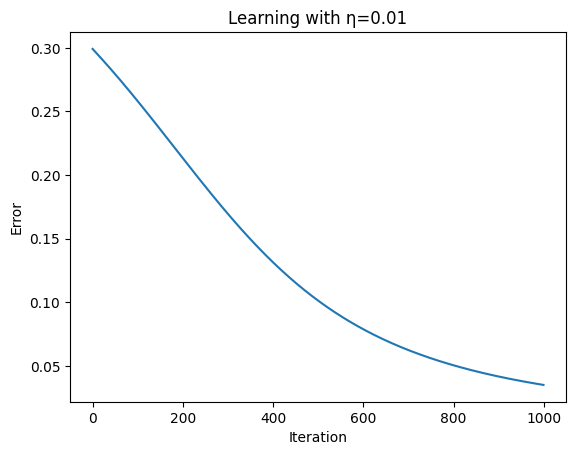

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x1=np.array([0])
x2=np.array([0])
y=[0] # target


# Learning rate (try 0.01, 0.1, 1.0)
eta = 0.01

# Random initialization
np.random.seed(42)
w00, w01, w10, w11 = np.random.rand(4)
b1 = 1.0
w2, w3 = np.random.rand(2)
b2 = 1.0

earray=[]
itra=[]
iterations=1000

for itr in range(iterations):
    # Forward pass
    z1=w00*x1+w01*x2+b1
    z2=w10*x1+w11*x2+b1
    h1=1/(1+np.exp(-z1))
    h2=1/(1+np.exp(-z2))
    zout=w2*h1+w3*h2+b2
    o=1/(1+np.exp(-zout))

    # Error
    e=0.5*np.mean((o-y)**2)

    # Gradients (backprop)
    de_do=(o-y)
    do_dzout=o*(1-o)

    # Output layer
    de_dw2=np.mean(de_do*do_dzout*h1)
    de_dw3=np.mean(de_do*do_dzout*h2)
    de_db2=np.mean(de_do*do_dzout*1)

    # Hidden layer
    dzout_dh1=w2
    dzout_dh2=w3
    dh1_dz1=h1*(1-h1)
    dh2_dz2=h2*(1-h2)

    de_dw00=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
    de_dw01=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
    de_dw10=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
    de_dw11=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
    de_db1=np.mean(de_do*do_dzout*(dzout_dh1*dh1_dz1 + dzout_dh2*dh2_dz2)*1)

    # --- Weight Updates with learning rate η ---
    w00 -= eta*de_dw00
    w01 -= eta*de_dw01
    w10 -= eta*de_dw10
    w11 -= eta*de_dw11
    b1  -= eta*de_db1
    w2  -= eta*de_dw2
    w3  -= eta*de_dw3
    b2  -= eta*de_db2

    earray.append(e)
    itra.append(itr)

plt.plot(itra,earray)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title(f"Learning with η={eta}")
plt.show()


**3. Learning Rate(𝜂)=1.0**

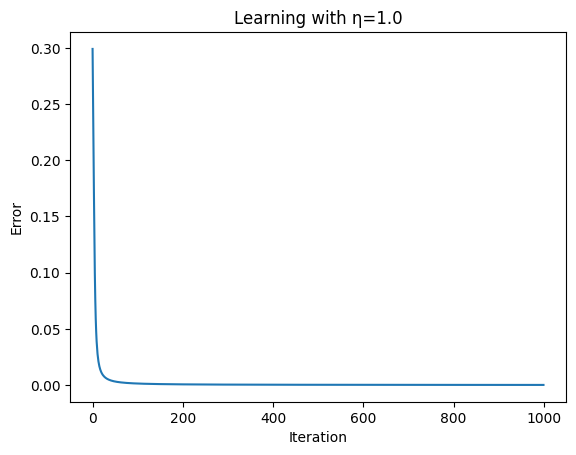

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x1=np.array([0])
x2=np.array([0])
y=[0] # target


# Learning rate (try 0.01, 0.1, 1.0)
eta = 1.0

# Random initialization
np.random.seed(42)
w00, w01, w10, w11 = np.random.rand(4)
b1 = 1.0
w2, w3 = np.random.rand(2)
b2 = 1.0

earray=[]
itra=[]
iterations=1000

for itr in range(iterations):
    # Forward pass
    z1=w00*x1+w01*x2+b1
    z2=w10*x1+w11*x2+b1
    h1=1/(1+np.exp(-z1))
    h2=1/(1+np.exp(-z2))
    zout=w2*h1+w3*h2+b2
    o=1/(1+np.exp(-zout))

    # Error
    e=0.5*np.mean((o-y)**2)

    # Gradients (backprop)
    de_do=(o-y)
    do_dzout=o*(1-o)

    # Output layer
    de_dw2=np.mean(de_do*do_dzout*h1)
    de_dw3=np.mean(de_do*do_dzout*h2)
    de_db2=np.mean(de_do*do_dzout*1)

    # Hidden layer
    dzout_dh1=w2
    dzout_dh2=w3
    dh1_dz1=h1*(1-h1)
    dh2_dz2=h2*(1-h2)

    de_dw00=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
    de_dw01=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
    de_dw10=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
    de_dw11=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
    de_db1=np.mean(de_do*do_dzout*(dzout_dh1*dh1_dz1 + dzout_dh2*dh2_dz2)*1)

    # --- Weight Updates with learning rate η ---
    w00 -= eta*de_dw00
    w01 -= eta*de_dw01
    w10 -= eta*de_dw10
    w11 -= eta*de_dw11
    b1  -= eta*de_db1
    w2  -= eta*de_dw2
    w3  -= eta*de_dw3
    b2  -= eta*de_db2

    earray.append(e)
    itra.append(itr)

plt.plot(itra,earray)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title(f"Learning with η={eta}")
plt.show()


**4. Learning Rate(𝜂)=1.5**

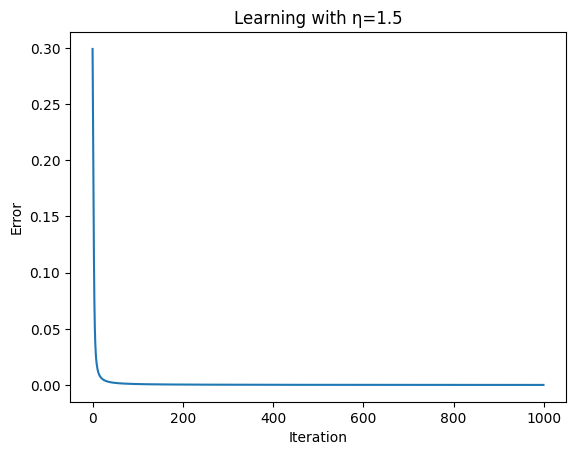

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x1=np.array([0])
x2=np.array([0])
y=[0] # target


# Learning rate (try 0.01, 0.1, 1.0)
eta = 1.5

# Random initialization
np.random.seed(42)
w00, w01, w10, w11 = np.random.rand(4)
b1 = 1.0
w2, w3 = np.random.rand(2)
b2 = 1.0

earray=[]
itra=[]
iterations=1000

for itr in range(iterations):
    # Forward pass
    z1=w00*x1+w01*x2+b1
    z2=w10*x1+w11*x2+b1
    h1=1/(1+np.exp(-z1))
    h2=1/(1+np.exp(-z2))
    zout=w2*h1+w3*h2+b2
    o=1/(1+np.exp(-zout))

    # Error
    e=0.5*np.mean((o-y)**2)

    # Gradients (backprop)
    de_do=(o-y)
    do_dzout=o*(1-o)

    # Output layer
    de_dw2=np.mean(de_do*do_dzout*h1)
    de_dw3=np.mean(de_do*do_dzout*h2)
    de_db2=np.mean(de_do*do_dzout*1)

    # Hidden layer
    dzout_dh1=w2
    dzout_dh2=w3
    dh1_dz1=h1*(1-h1)
    dh2_dz2=h2*(1-h2)

    de_dw00=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
    de_dw01=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
    de_dw10=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
    de_dw11=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
    de_db1=np.mean(de_do*do_dzout*(dzout_dh1*dh1_dz1 + dzout_dh2*dh2_dz2)*1)

    # --- Weight Updates with learning rate η ---
    w00 -= eta*de_dw00
    w01 -= eta*de_dw01
    w10 -= eta*de_dw10
    w11 -= eta*de_dw11
    b1  -= eta*de_db1
    w2  -= eta*de_dw2
    w3  -= eta*de_dw3
    b2  -= eta*de_db2

    earray.append(e)
    itra.append(itr)

plt.plot(itra,earray)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title(f"Learning with η={eta}")
plt.show()


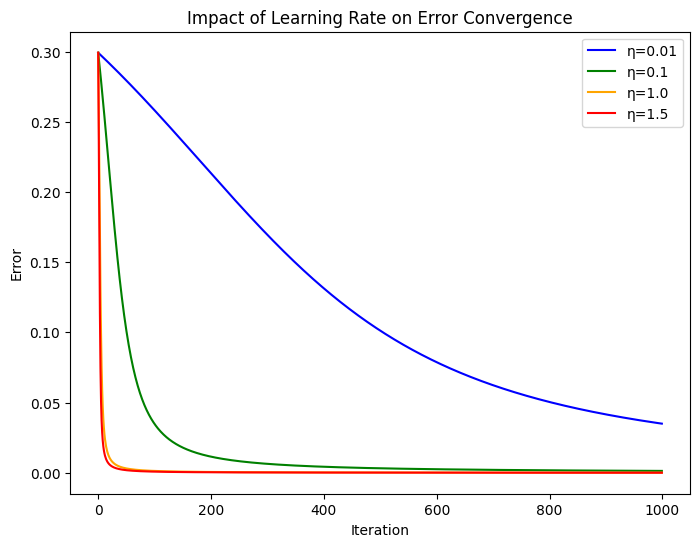

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x1=np.array([0])
x2=np.array([0])
y=[0] # target

iterations=1000
learning_rates=[0.01,0.1,1.0,1.5]
colors=['blue','green','orange','red']

plt.figure(figsize=(8,6))

for eta, c in zip(learning_rates, colors):
    # Random initialization (reset for each run)
    np.random.seed(42)
    w00, w01, w10, w11 = np.random.rand(4)
    b1 = 1.0
    w2, w3 = np.random.rand(2)
    b2 = 1.0

    earray=[]

    for itr in range(iterations):
        # Forward pass
        z1=w00*x1+w01*x2+b1
        z2=w10*x1+w11*x2+b1
        h1=1/(1+np.exp(-z1))
        h2=1/(1+np.exp(-z2))
        zout=w2*h1+w3*h2+b2
        o=1/(1+np.exp(-zout))

        # Error
        e=0.5*np.mean((o-y)**2)

        # Gradients (backprop)
        de_do=(o-y)
        do_dzout=o*(1-o)

        # Output layer
        de_dw2=np.mean(de_do*do_dzout*h1)
        de_dw3=np.mean(de_do*do_dzout*h2)
        de_db2=np.mean(de_do*do_dzout*1)

        # Hidden layer
        dzout_dh1=w2
        dzout_dh2=w3
        dh1_dz1=h1*(1-h1)
        dh2_dz2=h2*(1-h2)

        de_dw00=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
        de_dw01=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
        de_dw10=np.mean(de_do*do_dzout*dzout_dh1*dh1_dz1*x1)
        de_dw11=np.mean(de_do*do_dzout*dzout_dh2*dh2_dz2*x2)
        de_db1=np.mean(de_do*do_dzout*(dzout_dh1*dh1_dz1 + dzout_dh2*dh2_dz2)*1)

        # --- Weight Updates with learning rate η ---
        w00 -= eta*de_dw00
        w01 -= eta*de_dw01
        w10 -= eta*de_dw10
        w11 -= eta*de_dw11
        b1  -= eta*de_db1
        w2  -= eta*de_dw2
        w3  -= eta*de_dw3
        b2  -= eta*de_db2

        earray.append(e)

    # Plot for this η
    plt.plot(range(iterations), earray, color=c, label=f"η={eta}")

plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Impact of Learning Rate on Error Convergence")
plt.legend()
plt.show()


Looking at the plots, we can see how different learning rates impact the error convergence:

1. Learning Rate = 0.01 (blue line): The error decreases very slowly. This is an example of a "too small" learning rate. It will eventually converge, but it will take a long time.
2. Learning Rate = 0.1 (green line): The error decreases much faster than with a learning rate of 0.01 and converges nicely. This appears to be a good learning rate for this problem.
3. Learning Rate = 1.0 (orange line): The error decreases very rapidly at first, but then oscillates slightly before converging quickly. This learning rate is effective but might be slightly too large, leading to some instability.
4. Learning Rate = 1.5 (red line): The error also decreases very rapidly, similar to 1.0, and converges quickly. This learning rate also appears to be effective. For this specific problem and initialization, both 1.0 and 1.5 seem to work well and converge quickly.

In summary, a learning rate that is too small leads to slow convergence, while a learning rate that is too large can lead to oscillations or even divergence (though we don't see divergence in this specific example with these learning rates). Finding a good learning rate is crucial for efficient training.

**With functions from Tensorflow**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 200 - Error (MSE): 0.010259


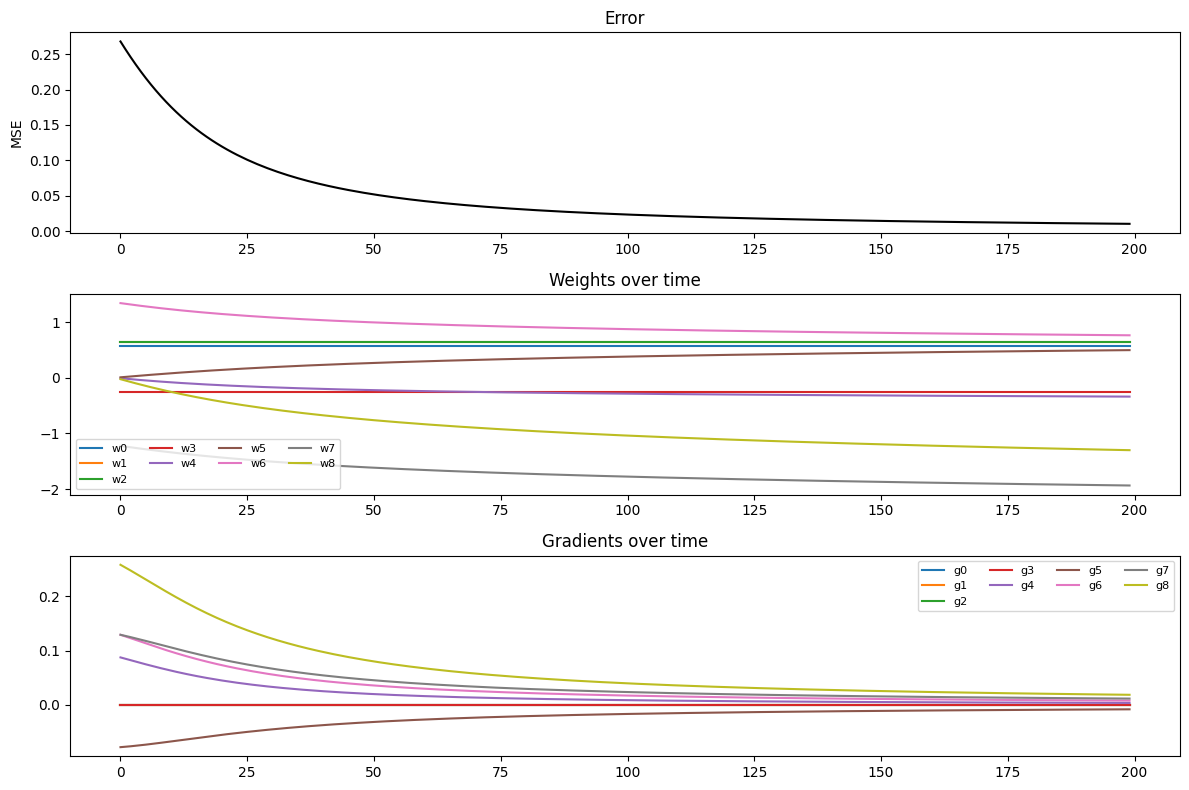

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Data (same as before: single input sample [0,0] -> output 0)
x = np.array([[0.0, 0.0]])
y = np.array([[0.0]])

# Build simple 2-2-1 neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(2, activation="sigmoid", input_shape=(2,)),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Optimizer and loss
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)
loss_fn = tf.keras.losses.MeanSquaredError()

# Logs
iterations = 200
earray = []
w_log = []
g_log = []

# Training loop (using TensorFlow functions)
for itr in range(iterations):
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = loss_fn(y, y_pred)

    # Get gradients
    grads = tape.gradient(loss, model.trainable_variables)

    # Apply update
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Log error, weights, gradients
    earray.append(loss.numpy())
    w_log.append(np.concatenate([w.numpy().flatten() for w in model.trainable_variables]))
    g_log.append(np.concatenate([g.numpy().flatten() for g in grads]))


# Convert to arrays for plotting
w_log = np.array(w_log)
g_log = np.array(g_log)

# Print error
print(f"Iteration {itr+1:03d} - Error (MSE): {loss.numpy():.6f}")


# ---- PLOTS ----
plt.figure(figsize=(12,8))

# Error
plt.subplot(3,1,1)
plt.plot(earray, 'k')
plt.title("Error")
plt.ylabel("MSE")

# Weights
plt.subplot(3,1,2)
for i in range(w_log.shape[1]):
    plt.plot(w_log[:,i], label=f"w{i}")
plt.title("Weights over time")
plt.legend(loc="best", ncol=4, fontsize=8)

# Gradients
plt.subplot(3,1,3)
for i in range(g_log.shape[1]):
    plt.plot(g_log[:,i], label=f"g{i}")
plt.title("Gradients over time")
plt.legend(loc="best", ncol=4, fontsize=8)

plt.tight_layout()
plt.show()
